In [1]:
# =============================================================
# NYT MEDIA PERCEPTION ANALYSIS: X (formerly Twitter)
# Data source: New York Times Article Search API
# =============================================================

import requests
import pandas as pd
import re
import json
import time
import matplotlib.pyplot as plt
from google.colab import userdata

# -----------------------
# Configuration
# -----------------------
NYT_API_KEY  = userdata.get("NYT_API_KEY")
FROM_DATE    = "20221001"   # NYT uses YYYYMMDD format
TO_DATE      = "20260301"
SOURCE_NAME  = "The New York Times"

if not NYT_API_KEY:
    raise RuntimeError("NYT_API_KEY not found in Colab Secrets — add it via 🔑 panel")

print(f"✓ NYT API key loaded")
print(f"Timeframe: {FROM_DATE} → {TO_DATE}")

✓ NYT API key loaded
Timeframe: 20221001 → 20260301


In [2]:
# =============================================================
# DATA EXTRACTION — NYT Article Search API
# =============================================================

# Boolean query — Lucene syntax. NYT supports OR, AND, parentheses.
# Restrict to relevant news desks (NYT's equivalent of Guardian sections).
NYT_QUERY = (
    '("Twitter" OR "X Corp" OR "X platform" OR "Musk\'s X" '
    'OR "formerly Twitter" OR "Yaccarino")'
)

# news_desk filter — keeps results in tech/business/media coverage
NEWS_DESK_FILTER = (
    'news_desk:("Business" "Technology" "Media" "Foreign")'
)

base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
all_articles = []
MAX_PAGES = 100   # NYT allows up to 100 pages × 10 = 1,000 articles per query

for page in range(MAX_PAGES):
    params = {
        "q":           NYT_QUERY,
        "fq":          NEWS_DESK_FILTER,
        "begin_date":  FROM_DATE,
        "end_date":    TO_DATE,
        "page":        page,
        "sort":        "newest",
        "api-key":     NYT_API_KEY,
    }

    try:
        r = requests.get(base_url, params=params, timeout=15)

        # Handle rate limit (429) with back-off
        if r.status_code == 429:
            print(f"Rate limited on page {page}, waiting 60s...")
            time.sleep(60)
            r = requests.get(base_url, params=params, timeout=15)

        r.raise_for_status()
        data = r.json()

        if data.get("status") != "OK":
            print(f"API error on page {page}: {data.get('errors')}")
            break

        docs = data["response"]["docs"]
        if not docs:
            print(f"Page {page}: no more results — stopping")
            break

        all_articles.extend(docs)
        hits = data["response"]["meta"]["hits"]
        print(f"Page {page}: +{len(docs)} articles  (total available: {hits})")

        # NYT rate limit: 5 requests per minute → wait 12s between calls
        time.sleep(12)

        # Stop if we've fetched all available
        if (page + 1) * 10 >= hits:
            break

    except requests.exceptions.RequestException as e:
        print(f"Request error on page {page}: {e}")
        break

print(f"\n✓ Total NYT articles retrieved: {len(all_articles)}")

Page 0: no more results — stopping

✓ Total NYT articles retrieved: 0


In [4]:
# Inspect the actual NYT response structure
import requests, json

test_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"
r = requests.get(test_url, params={
    "q":       "Twitter",
    "api-key": NYT_API_KEY,
}, timeout=15)

print(f"Status: {r.status_code}")
data = r.json()

# Show top-level structure
print(f"\nTop-level keys: {list(data.keys())}")

if "response" in data:
    print(f"Response keys: {list(data['response'].keys())}")

# Show the raw response (truncated to fit)
print("\n--- Full response (first 2,500 chars) ---")
print(json.dumps(data, indent=2)[:2500])

Status: 200

Top-level keys: ['status', 'copyright', 'response']
Response keys: ['docs', 'metadata']

--- Full response (first 2,500 chars) ---
{
  "status": "OK",
  "copyright": "Copyright (c) 2026 The New York Times Company. All Rights Reserved.",
  "response": {
    "docs": [
      {
        "abstract": "Mr. Musk said he did not expect his posts in the lead-up to his 2022 acquisition of the social media site, now X, to affect the company\u2019s share price.",
        "byline": {
          "original": "By Kate Conger"
        },
        "document_type": "article",
        "headline": {
          "main": "Elon Musk Defends Social Media Posts in Twitter Shareholder Lawsuit",
          "kicker": "",
          "print_headline": "Musk Defends Social Media Posts In Twitter Shareholder Lawsuit"
        },
        "_id": "nyt://article/c0287c36-f156-5caf-8861-df5e85c7359e",
        "keywords": [
          {
            "name": "Subject",
            "value": "Mergers, Acquisitions and Divest

In [8]:
# =============================================================
# DATA EXTRACTION — NYT Article Search (multi-query strategy)
# =============================================================
import time
import requests

base_url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

# Multiple narrow queries that each return ~hundreds of relevant articles.
# We'll merge and dedupe afterwards by article ID.
QUERIES = [
    "Twitter Musk",         # core acquisition / Musk era
    "Twitter layoffs",      # the layoffs story
    "Twitter advertisers",  # advertiser exodus
    "Twitter moderation",   # content moderation
    "Twitter rebrand",      # rebrand to X
    "X Yaccarino",          # CEO era
    "Twitter Brazil",       # Brazil ban
    "Twitter Threads",      # Meta competition
    "Musk acquisition",     # acquisition coverage
    "Twitter regulation",   # EU / DSA
]

FROM_DATE = "20221001"
TO_DATE   = "20260301"

all_articles_dict = {}   # use dict keyed by article id to dedupe
MAX_PAGES_PER_QUERY = 50  # cap each query at 500 articles

for q_index, query in enumerate(QUERIES):
    print(f"\n=== Query {q_index + 1}/{len(QUERIES)}: '{query}' ===")
    fetched_for_query = 0

    for page in range(MAX_PAGES_PER_QUERY):
        params = {
            "q":          query,
            "begin_date": FROM_DATE,
            "end_date":   TO_DATE,
            "page":       page,
            "sort":       "newest",
            "api-key":    NYT_API_KEY,
        }

        try:
            r = requests.get(base_url, params=params, timeout=15)

            # Handle rate limit
            if r.status_code == 429:
                print(f"  Rate limited, sleeping 60s...")
                time.sleep(60)
                r = requests.get(base_url, params=params, timeout=15)

            r.raise_for_status()
            data = r.json()

            if data.get("status") != "OK":
                print(f"  API error: {data.get('errors')}")
                break

            response = data.get("response") or {}
            docs = response.get("docs") or []

            if not docs:
                break

            for d in docs:
                _id = d.get("_id")
                if _id and _id not in all_articles_dict:
                    all_articles_dict[_id] = d
                    fetched_for_query += 1

            meta = response.get("metadata") or {}
            hits = meta.get("hits", "?")
            print(f"  Page {page}: +{len(docs)}  (query has {hits} hits, "
                  f"unique total so far: {len(all_articles_dict)})")

            time.sleep(13)   # NYT free tier: 5 rpm = 12s safe minimum

            if isinstance(hits, int) and (page + 1) * 10 >= hits:
                break

        except requests.exceptions.RequestException as e:
            print(f"  Request error: {e}")
            break

    print(f"  → New unique articles from this query: {fetched_for_query}")

all_articles = list(all_articles_dict.values())
print(f"\n{'=' * 60}")
print(f"✓ Total unique NYT articles retrieved: {len(all_articles)}")
print(f"{'=' * 60}")


=== Query 1/10: 'Twitter Musk' ===
  Page 0: +10  (query has 1566 hits, unique total so far: 10)
  Page 1: +10  (query has 1566 hits, unique total so far: 20)
  Page 2: +10  (query has 1566 hits, unique total so far: 30)
  Page 3: +10  (query has 1566 hits, unique total so far: 40)
  Page 4: +10  (query has 1566 hits, unique total so far: 50)
  Page 5: +10  (query has 1566 hits, unique total so far: 60)
  Page 6: +10  (query has 1566 hits, unique total so far: 70)
  Page 7: +10  (query has 1566 hits, unique total so far: 80)
  Page 8: +10  (query has 1566 hits, unique total so far: 90)
  Page 9: +10  (query has 1566 hits, unique total so far: 100)
  Page 10: +10  (query has 1566 hits, unique total so far: 110)
  Page 11: +10  (query has 1566 hits, unique total so far: 120)
  Page 12: +10  (query has 1566 hits, unique total so far: 130)
  Page 13: +10  (query has 1566 hits, unique total so far: 140)
  Page 14: +10  (query has 1566 hits, unique total so far: 150)
  Page 15: +10  (query 

KeyboardInterrupt: 

In [9]:
# How many unique articles were collected before we stopped?
print(f"Collected so far: {len(all_articles_dict)}")

# Date range of what was fetched
if all_articles_dict:
    sample_dates = sorted([d.get("pub_date", "") for d in all_articles_dict.values() if d.get("pub_date")])
    print(f"Date range: {sample_dates[0][:10]} → {sample_dates[-1][:10]}")
    print(f"Sample headlines:")
    for d in list(all_articles_dict.values())[:5]:
        print(f"  - [{d.get('pub_date','')[:10]}] {d['headline']['main']}")

Collected so far: 2330
Date range: 2022-10-01 → 2026-02-28
Sample headlines:
  - [2026-02-28] Lloyd Blankfein on Trump, Epstein and Life After Goldman Sachs
  - [2026-02-27] Elon Musk’s Secret Web of Companies in Texas
  - [2026-02-20] Who Has the Power in Trump’s White House?
  - [2026-02-17] Did That Bald Head Get Your Attention? One Start-Up Hopes So.
  - [2026-02-11] Affordability and the ‘Epstein Class’ Will Define American Politics


In [10]:
# Convert dict to list and save raw fetch
all_articles = list(all_articles_dict.values())

# Save raw JSON as backup
import json
with open("nyt_raw_fetch.json", "w") as f:
    json.dump(all_articles, f, indent=2)

print(f"✓ Saved {len(all_articles)} raw articles to nyt_raw_fetch.json")

# Download to your machine for safety
try:
    from google.colab import files
    files.download("nyt_raw_fetch.json")
except ImportError:
    pass

✓ Saved 2330 raw articles to nyt_raw_fetch.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd

rows = []
for art in all_articles:
    rows.append({
        "id":             art.get("_id"),
        "date":           art.get("pub_date"),
        "section":        art.get("section_name"),
        "news_desk":      art.get("news_desk"),
        "headline":       (art.get("headline") or {}).get("main", ""),
        "abstract":       art.get("abstract", ""),
        "lead_paragraph": art.get("lead_paragraph", ""),
        "snippet":        art.get("snippet", ""),
        "byline":         (art.get("byline") or {}).get("original", ""),
        "word_count":     art.get("word_count"),
        "url":            art.get("web_url"),
        "source":         "The New York Times",
    })

df_raw = pd.DataFrame(rows)
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce", utc=True)
df_raw["word_count"] = pd.to_numeric(df_raw["word_count"], errors="coerce")
df_raw = df_raw.drop_duplicates(subset="id").sort_values("date").reset_index(drop=True)

print(f"Raw NYT DataFrame: {len(df_raw)} articles")
print(f"\nNews desks (top 15):")
print(df_raw["news_desk"].value_counts().head(15))
print(f"\nSection names (top 15):")
print(df_raw["section"].value_counts().head(15))

Raw NYT DataFrame: 2330 articles

News desks (top 15):
news_desk
Business          756
OpEd              509
Styles            138
NYTNow            131
Foreign           107
Podcasts           98
Washington         83
                   74
Politics           69
SundayBusiness     50
Magazine           43
Culture            36
Express            32
Metro              31
National           26
Name: count, dtype: int64

Section names (top 15):
section
Opinion                 524
Business                503
Technology              315
U.S.                    214
Style                   137
Briefing                132
World                   120
Podcasts                117
Magazine                 70
Arts                     49
New York                 39
Books                    19
Sports                   19
Travel                   16
The Learning Network      9
Name: count, dtype: int64


In [12]:
# =============================================================
# CLEANING PIPELINE — NYT
# Adapted from Guardian methodology with NYT-specific desk filter
# =============================================================
import re

df = df_raw.copy()
print(f"Starting: {len(df)} articles\n")

# ---- Layer 1: keep only relevant news desks AND/OR sections ----
# We accept Business, Technology, Opinion/OpEd, SundayBusiness as
# substantively-on-topic editorial categories. Everything else is noise.

ALLOWED_NEWS_DESKS = {"Business", "OpEd", "SundayBusiness"}
ALLOWED_SECTIONS   = {"Business", "Technology", "Opinion"}

def is_relevant_desk_or_section(row):
    return (row["news_desk"] in ALLOWED_NEWS_DESKS) or \
           (row["section"]   in ALLOWED_SECTIONS)

before = len(df)
df = df[df.apply(is_relevant_desk_or_section, axis=1)].reset_index(drop=True)
print(f"Layer 1 — desk/section filter: -{before - len(df)} → {len(df)}")

# ---- Layer 2: drop wire-feed/briefing-style entries ----
briefing_pat = re.compile(
    r"briefing|live updates?|today\'?s headlines|morning report|"
    r"the daily|here are the|what we learned",
    flags=re.IGNORECASE,
)
before = len(df)
df = df[~df["headline"].str.contains(briefing_pat, na=False)].reset_index(drop=True)
print(f"Layer 2 — dropped briefings/wire feeds: -{before - len(df)} → {len(df)}")

# ---- Layer 3: platform-mention filter ----
# Same regex pattern as Guardian, applied to NYT fields.
# We check headline + abstract + lead_paragraph (NYT's snippet field is short).
platform_pat = re.compile(
    r"""
    \btwitter\b
    | \btweet(s|ed|ing)?\b
    | \bretweet
    | \bX\s+Corp\b
    | formerly\s+Twitter
    | Twitter/X
    | \bYaccarino\b
    | Musk'?s\s+(?:X\b|social\s+media|platform|site|network|app|company)
    | social\s+(?:media\s+)?(?:platform|network|site)\s+(?:X|formerly\s+Twitter)
    | \bX\s+(?:users?|accounts?|posts?|employees?|staff|CEO|fined|banned|
            sued|suspended|algorithm|advertisers?|moderation)\b
    | post(?:s|ed|ing)?\s+on\s+X\b
    | owner\s+of\s+X\b
    """,
    flags=re.IGNORECASE | re.VERBOSE,
)

def mentions_platform(row):
    text = f"{row['headline']} {row['abstract']} {row['lead_paragraph']}"
    return bool(platform_pat.search(text))

before = len(df)
df = df[df.apply(mentions_platform, axis=1)].reset_index(drop=True)
print(f"Layer 3 — platform-mention filter: -{before - len(df)} → {len(df)}")

# ---- Layer 4: drop headlines led by Tesla/SpaceX ----
tesla_primary_pat = re.compile(
    r"^[^:]*\b(?:Tesla|SpaceX|Starship|Cybertruck|Neuralink|Starlink)\b",
    flags=re.IGNORECASE,
)
before = len(df)
df = df[~df["headline"].str.contains(tesla_primary_pat, na=False)].reset_index(drop=True)
print(f"Layer 4 — dropped Tesla/SpaceX-led: -{before - len(df)} → {len(df)}")

# ---- Tag opinion pieces for separate analysis if needed ----
df["is_opinion"] = (df["news_desk"] == "OpEd") | (df["section"] == "Opinion")

print(f"\n✓ Clean NYT dataset: {len(df)} articles")
print(f"  ({df['is_opinion'].sum()} opinion pieces, "
      f"{(~df['is_opinion']).sum()} news/business reporting)")

Starting: 2330 articles

Layer 1 — desk/section filter: -960 → 1370
Layer 2 — dropped briefings/wire feeds: -1 → 1369
Layer 3 — platform-mention filter: -1164 → 205
Layer 4 — dropped Tesla/SpaceX-led: -5 → 200

✓ Clean NYT dataset: 200 articles
  (19 opinion pieces, 181 news/business reporting)


In [13]:
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

print(f"\nNews desks:")
print(df["news_desk"].value_counts())

print(f"\nSections:")
print(df["section"].value_counts())

print(f"\nMonthly timeline:")
print(df.set_index("date").resample("ME").size().to_string())

print(f"\n--- 12 random headlines (sanity check) ---")
display(df.sample(min(12, len(df)), random_state=42)
          [["date", "news_desk", "section", "is_opinion", "headline"]])

# Save the clean dataset
df.to_csv("nyt_x_clean.csv", index=False)
print(f"\n✓ Saved nyt_x_clean.csv ({len(df)} rows)")

Date range: 2022-10-04 → 2025-07-09

News desks:
news_desk
Business          164
OpEd               17
SundayBusiness     10
Express             4
                    2
Editorial           1
Letters             1
Investigative       1
Name: count, dtype: int64

Sections:
section
Technology    127
Business       54
Opinion        19
Name: count, dtype: int64

Monthly timeline:
date
2022-10-31 00:00:00+00:00    40
2022-11-30 00:00:00+00:00    42
2022-12-31 00:00:00+00:00    20
2023-01-31 00:00:00+00:00     5
2023-02-28 00:00:00+00:00     7
2023-03-31 00:00:00+00:00     7
2023-04-30 00:00:00+00:00    11
2023-05-31 00:00:00+00:00     9
2023-06-30 00:00:00+00:00     3
2023-07-31 00:00:00+00:00    17
2023-08-31 00:00:00+00:00     2
2023-09-30 00:00:00+00:00     1
2023-10-31 00:00:00+00:00     5
2023-11-30 00:00:00+00:00     5
2023-12-31 00:00:00+00:00     0
2024-01-31 00:00:00+00:00     1
2024-02-29 00:00:00+00:00     1
2024-03-31 00:00:00+00:00     2
2024-04-30 00:00:00+00:00     1
2024-05-

,date,news_desk,section,is_opinion,headline
95,2022-12-19 02:36:39+00:00,Business,Technology,False,‘The Last Straw’: Twitter Users Rage Over Elon...
15,2022-10-26 07:00:10+00:00,Business,Technology,False,Elon Musk Seems to Answer to No One. Except fo...
30,2022-10-28 20:29:55+00:00,Business,Technology,False,Elon Musk moves to form a content moderation c...
158,2023-07-27 21:00:08+00:00,OpEd,Opinion,True,What’s in a Name? Musk/Twitter Edition
128,2023-04-14 09:00:23+00:00,OpEd,Opinion,True,"Twitter Is Broken. Thanks, Elon."
115,2023-03-08 00:29:21+00:00,Business,Technology,False,F.T.C. Intensifies Investigation of Twitter’s ...
69,2022-11-18 19:05:47+00:00,OpEd,Opinion,True,I Was the Head of Trust and Safety at Twitter....
170,2023-11-17 22:50:43+00:00,Business,Technology,False,Advertisers Flee X as Outcry Over Musk’s Endor...
174,2024-01-31 15:41:03+00:00,Business,Technology,False,"X’s chief executive, Linda Yaccarino, faces la..."
45,2022-11-03 21:01:00+00:00,Business,Technology,False,"Elon Musk, Under Financial Pressure, Pushes to..."



✓ Saved nyt_x_clean.csv (200 rows)


In [17]:
# =============================================================
# AUTHENTICATE GEMINI & PREPARE NYT PROMPT TEXTS
# =============================================================
import pandas as pd
from google import genai
from google.colab import userdata

# Authenticate Gemini
client = genai.Client(api_key=userdata.get("Gemini_API_Key"))
print("✓ Gemini client authenticated")

# Reload the clean NYT dataset
df = pd.read_csv("nyt_x_clean.csv", parse_dates=["date"])
print(f"✓ Loaded {len(df)} clean NYT articles")

# Build prompt_text for each article — NYT version
def prepare_nyt_text(row):
    headline = row.get("headline") or ""
    abstract = row.get("abstract") or ""
    lead     = row.get("lead_paragraph") or ""
    return (
        f"Date: {row['date'].strftime('%Y-%m-%d')}\n"
        f"News desk: {row.get('news_desk', '')}\n"
        f"Section: {row.get('section', '')}\n"
        f"Headline: {headline}\n"
        f"Abstract: {abstract}\n"
        f"Lead paragraph: {lead}"
    )

df["prompt_text"] = df.apply(prepare_nyt_text, axis=1)

# Drop rows where there's nothing for Gemini to analyse
before = len(df)
df = df[df["abstract"].notna() | df["lead_paragraph"].notna()].reset_index(drop=True)
print(f"After dropping empty texts: {len(df)} ({before - len(df)} dropped)")

# Inspect one prepared example
print("\n--- Example prepared text ---")
print(df.iloc[0]["prompt_text"][:800])

✓ Gemini client authenticated
✓ Loaded 200 clean NYT articles
After dropping empty texts: 197 (3 dropped)

--- Example prepared text ---
Date: 2022-10-04
News desk: Business
Section: Technology
Headline: The Board Chair Squaring Up to Elon Musk in the Feud Over Twitter
Abstract: Bret Taylor, an understated executive, led talks with Elon Musk over his plans to acquire the company and the legal fight to seal the deal.
Lead paragraph: nan


In [18]:
# Quick patch: replace any "nan" strings in prompt_text
import pandas as pd

def prepare_nyt_text_v2(row):
    headline = row.get("headline") if pd.notna(row.get("headline")) else ""
    abstract = row.get("abstract") if pd.notna(row.get("abstract")) else ""
    lead     = row.get("lead_paragraph") if pd.notna(row.get("lead_paragraph")) else ""

    parts = [
        f"Date: {row['date'].strftime('%Y-%m-%d')}",
        f"News desk: {row.get('news_desk', '')}",
        f"Section: {row.get('section', '')}",
        f"Headline: {headline}",
    ]
    if abstract:
        parts.append(f"Abstract: {abstract}")
    if lead:
        parts.append(f"Lead paragraph: {lead}")

    return "\n".join(parts)

df["prompt_text"] = df.apply(prepare_nyt_text_v2, axis=1)

# Verify the fix
print("--- Cleaned example ---")
print(df.iloc[0]["prompt_text"])

--- Cleaned example ---
Date: 2022-10-04
News desk: Business
Section: Technology
Headline: The Board Chair Squaring Up to Elon Musk in the Feud Over Twitter
Abstract: Bret Taylor, an understated executive, led talks with Elon Musk over his plans to acquire the company and the legal fight to seal the deal.


In [19]:
# =============================================================
# PASS 1 — NYT GEMINI CLASSIFICATION
# Same prompt and structure as Guardian, applied to NYT dataset.
# =============================================================
import json, time, os
from google.genai import types
from tqdm import tqdm

SYSTEM_INSTRUCTION = """You are a senior media intelligence analyst evaluating New York Times coverage of X (formerly Twitter) since Elon Musk's October 2022 acquisition.

Return a JSON object with these exact fields:

- sentiment: one of [very_negative, negative, neutral, positive, very_positive]
- sentiment_rationale: ONE sentence explaining the score
- primary_theme: ONE of [acquisition, layoffs, content_moderation, advertiser_relations,
  rebrand_strategy, regulation_legal, leadership, platform_competition,
  misinformation, financial_performance, user_experience, other]
- driver_event: specific event in 5 words or fewer, or null
- stance_toward_company: one of [critical, neutral, sympathetic]

Score the article's portrayal of X/Twitter as a company or platform, not Musk personally unless he is the subject AS owner.

Return ONLY valid JSON. No prose, no markdown."""

def analyse_article(prompt_text, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt_text,
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_INSTRUCTION,
                    response_mime_type="application/json",
                    temperature=0,
                ),
            )
            return json.loads(response.text), None
        except Exception as e:
            if attempt == max_retries - 1:
                return None, str(e)
            time.sleep(2 ** attempt)

# -----------------------
# Resume-friendly setup
# -----------------------
RESULTS_FILE = "nyt_gemini_analysis.csv"

if os.path.exists(RESULTS_FILE):
    results_df = pd.read_csv(RESULTS_FILE)
    done_ids = set(results_df.dropna(subset=["sentiment"])["id"].tolist())
    print(f"Resuming — {len(done_ids)} valid records already on disk")
else:
    results_df = pd.DataFrame()
    done_ids = set()

to_process = df[~df["id"].isin(done_ids)].reset_index(drop=True)
print(f"To analyse: {len(to_process)} articles\n")

new_rows = []
errors = []
SAVE_EVERY = 25

for i, row in tqdm(to_process.iterrows(), total=len(to_process), desc="Analysing"):
    result, error = analyse_article(row["prompt_text"])

    record = {
        "id":         row["id"],
        "date":       row["date"],
        "news_desk":  row["news_desk"],
        "section":    row["section"],
        "is_opinion": row["is_opinion"],
        "headline":   row["headline"],
        "url":        row["url"],
    }
    if result:
        record.update(result)
    else:
        errors.append({"id": row["id"], "headline": row["headline"], "error": error})
        record.update({
            "sentiment": None, "sentiment_rationale": None,
            "primary_theme": None, "driver_event": None,
            "stance_toward_company": None,
        })
    new_rows.append(record)

    if (i + 1) % SAVE_EVERY == 0:
        partial = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
        partial.to_csv(RESULTS_FILE, index=False)

results_df = pd.concat([results_df, pd.DataFrame(new_rows)], ignore_index=True)
results_df["date"] = pd.to_datetime(results_df["date"], errors="coerce")
results_df.to_csv(RESULTS_FILE, index=False)

print(f"\n✓ Total records: {len(results_df)}")
print(f"✓ Successfully analysed: {results_df['sentiment'].notna().sum()}")
print(f"✗ Failed: {results_df['sentiment'].isna().sum()}")

print("\n--- Sentiment distribution ---")
print(results_df["sentiment"].value_counts())

print("\n--- Top themes ---")
print(results_df["primary_theme"].value_counts().head(8))

print("\n--- Sample results ---")
display(results_df.dropna(subset=["sentiment"])
                  [["date", "headline", "sentiment", "primary_theme", "driver_event"]]
                  .sample(min(5, results_df["sentiment"].notna().sum()), random_state=42))

To analyse: 197 articles



Analysing: 100%|██████████| 197/197 [11:07<00:00,  3.39s/it]


✓ Total records: 197
✓ Successfully analysed: 197
✗ Failed: 0

--- Sentiment distribution ---
sentiment
negative         119
neutral           38
very_negative     32
positive           8
Name: count, dtype: int64

--- Top themes ---
primary_theme
content_moderation       36
acquisition              33
leadership               19
layoffs                  18
financial_performance    17
platform_competition     15
rebrand_strategy         13
advertiser_relations     13
Name: count, dtype: int64

--- Sample results ---


,date,headline,sentiment,primary_theme,driver_event
140,2023-06-14 20:22:12+00:00,"Music Publishers Sue Twitter, Accusing It of C...",negative,regulation_legal,Copyright infringement lawsuit
113,2023-03-08 00:29:21+00:00,F.T.C. Intensifies Investigation of Twitter’s ...,negative,regulation_legal,FTC investigation intensifies
16,2022-10-26 19:14:31+00:00,Elon Musk Visits Twitter as $44 Billion Deal N...,neutral,acquisition,Musk visits Twitter HQ
75,2022-11-22 20:41:38+00:00,SPAC Linked to Trump’s Media Company Is Grante...,neutral,content_moderation,Trump's Twitter reinstatement
155,2023-07-27 14:10:09+00:00,Elon Musk’s Quixotic Quest to Turn X Into an ‘...,negative,rebrand_strategy,Rebrand to X


In [27]:
# =============================================================
# NYT — PASS 2: SENTIMENT EVOLUTION & EXECUTIVE SUMMARY
# =============================================================
import pandas as pd
from google.genai import types

# -----------------------
# 1. Load and aggregate Pass 1 results
# -----------------------
results = pd.read_csv("nyt_gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"] = results["date"].dt.to_period("M").astype(str)

monthly_summary = (
    results.groupby("month")
           .agg(
               article_count = ("id", "count"),
               avg_sentiment = ("sentiment_score", "mean"),
               very_negative = ("sentiment", lambda s: (s == "very_negative").sum()),
               negative      = ("sentiment", lambda s: (s == "negative").sum()),
               neutral       = ("sentiment", lambda s: (s == "neutral").sum()),
               positive      = ("sentiment", lambda s: (s == "positive").sum()),
               very_positive = ("sentiment", lambda s: (s == "very_positive").sum()),
               top_themes    = ("primary_theme",
                                lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
               top_drivers   = ("driver_event",
                                lambda s: ", ".join(s.dropna().value_counts().head(3).index.tolist())),
           )
           .reset_index()
)
monthly_summary["avg_sentiment"] = monthly_summary["avg_sentiment"].round(2)

print(f"Aggregated {len(results)} NYT articles into {len(monthly_summary)} months")
display(monthly_summary.head(10))

# -----------------------
# 2. Synthesis prompt
# -----------------------
summary_table_text = monthly_summary.to_string(index=False)

SYNTHESIS_PROMPT = f"""You are a senior media intelligence consultant analysing how The New York Times has covered X (formerly Twitter) since Elon Musk's October 2022 acquisition.

Below is a monthly summary of {len(results)} NYT articles. Sentiment scores range from -2 (very negative) to +2 (very positive). Use ONLY the data provided — do not invent figures.

DATA:
{summary_table_text}

Answer the following research question, in the exact structure shown.

RESEARCH QUESTION:
How has NYT's media perception of X (formerly Twitter) evolved over time, and what are the key drivers behind this change?

REQUIRED OUTPUT FORMAT (use these exact headings):

## 1. Overall sentiment evolution over time
- 4-6 bullet points
- Cite specific months and average sentiment scores from the data
- Identify distinct phases (e.g. acute crisis, transition, post-rebrand)

## 2. Significant spikes and drops in sentiment
- 3-5 bullet points
- Each bullet must name: the month, the direction of the shift, the magnitude (numeric), and the likely driver event from the data
- Reference top_drivers and top_themes columns to justify causation

## 3. Executive summary (max 120 words)
- Single paragraph, no bullets
- Written for a board-level audience
- Explain what the trajectory suggests about X's reputational position and strategic situation
- Strictly under 120 words

Return your answer in clean Markdown using the exact headings above."""

# -----------------------
# 3. Send to Gemini
# -----------------------
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=SYNTHESIS_PROMPT,
    config=types.GenerateContentConfig(temperature=0.2),
)

executive_analysis = response.text

# -----------------------
# 4. Display and save
# -----------------------
print("\n" + "=" * 70)
print("NYT — EXECUTIVE ANALYSIS")
print("=" * 70 + "\n")
print(executive_analysis)

with open("nyt_executive_analysis.md", "w") as f:
    f.write(executive_analysis)
monthly_summary.to_csv("nyt_monthly_summary.csv", index=False)

print("\n✓ Saved: nyt_executive_analysis.md")
print("✓ Saved: nyt_monthly_summary.csv")

Aggregated 197 NYT articles into 29 months


/tmp/ipykernel_1724/2690349161.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"] = results["date"].dt.to_period("M").astype(str)


,month,article_count,avg_sentiment,very_negative,negative,neutral,positive,very_positive,top_themes,top_drivers
0,2022-10,38,-0.53,1,20,15,2,0,"acquisition, content_moderation, layoffs","Musk acquires Twitter, Musk's acquisition, Leg..."
1,2022-11,42,-1.10,10,27,4,1,0,"layoffs, content_moderation, acquisition","Musk's acquisition, Antisemitism accusation, F..."
2,2022-12,20,-1.10,5,13,1,1,0,"content_moderation, leadership, advertiser_rel...","Journalist suspensions, Apple dispute resolved..."
3,2023-01,5,-0.60,0,3,2,0,0,"financial_performance, content_moderation, other","Relaxing political ad ban, Selling usernames, ..."
4,2023-02,7,-1.29,2,5,0,0,0,"content_moderation, user_experience, layoffs","Lawsuit for non-payment, Platform outage, Twit..."
5,2023-03,7,-1.00,0,7,0,0,0,"financial_performance, regulation_legal, other","Musk apologizes to employee, FTC investigation..."
6,2023-04,11,-1.09,2,8,1,0,0,"user_experience, platform_competition, content...","Senior lawyer resigns, Substack launches rival..."
7,2023-05,9,-0.11,0,4,2,3,0,"platform_competition, content_moderation, lead...","Dorsey posts on new networks, Texas shooting i..."
8,2023-06,3,-1.00,1,1,1,0,0,"financial_performance, regulation_legal, leade...","Ad sales plunge, Copyright infringement lawsui..."
9,2023-07,17,-0.82,1,12,4,0,0,"platform_competition, rebrand_strategy, acquis...","Threads launch, Rebranding to X, Twitter sues ..."



NYT — EXECUTIVE ANALYSIS

## 1. Overall sentiment evolution over time
*   The initial period post-acquisition (October 2022 - March 2023) was characterized by acutely negative sentiment, starting at -0.53 and quickly plummeting to -1.10 in November and December 2022, reaching its lowest point of -1.29 in February 2023, driven by layoffs and content moderation issues.
*   A brief respite occurred in May 2023, with sentiment improving significantly to -0.11, coinciding with increased focus on platform competition and leadership discussions.
*   The rebrand to X in July 2023 saw sentiment at -0.82, briefly becoming neutral in August 2023 (0.00), but this positive shift was short-lived.
*   The period from October to November 2023 marked a return to deeply negative sentiment, with scores of -1.20 and -1.60 respectively, largely driven by advertiser relations and content moderation controversies, including Musk's antisemitic post.
*   From late 2023 through mid-2025, coverage became sparse

In [28]:
# =============================================================
# NYT — PASS 3: DRIVERS OF PERCEPTION CHANGE
# Identifies events, entities, and external factors driving shifts.
# =============================================================
import pandas as pd
from google.genai import types

# -----------------------
# 1. Load and aggregate Pass 1 results
# -----------------------
results = pd.read_csv("nyt_gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"] = results["date"].dt.to_period("M").astype(str)

# Monthly aggregate with month-on-month sentiment changes
monthly = (
    results.groupby("month")
           .agg(
               article_count = ("id", "count"),
               avg_sentiment = ("sentiment_score", "mean"),
               top_themes    = ("primary_theme",
                                lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
               top_drivers   = ("driver_event",
                                lambda s: ", ".join(s.dropna().value_counts().head(5).index.tolist())),
           )
           .reset_index()
)
monthly["avg_sentiment"]    = monthly["avg_sentiment"].round(2)
monthly["sentiment_change"] = monthly["avg_sentiment"].diff().round(2)

# Top drivers across the full dataset
top_drivers_overall = (results["driver_event"]
                       .dropna()
                       .value_counts()
                       .head(15)
                       .reset_index())
top_drivers_overall.columns = ["driver_event", "article_count"]

# -----------------------
# 2. Build the synthesis prompt
# -----------------------
monthly_text = monthly.to_string(index=False)
drivers_text = top_drivers_overall.to_string(index=False)

DRIVERS_PROMPT = f"""You are a senior media intelligence consultant analysing The New York Times' coverage of X (formerly Twitter) since Elon Musk's October 2022 acquisition.

You are given two structured tables built from {len(results)} classified NYT articles. Sentiment scores range from -2 (very negative) to +2 (very positive). Use ONLY the data provided — do not invent figures or events not present in the data.

TABLE A — MONTHLY SUMMARY (with month-on-month sentiment changes):
{monthly_text}

TABLE B — TOP 15 DRIVER EVENTS ACROSS THE WHOLE DATASET:
{drivers_text}

RESEARCH QUESTION:
What are the key drivers behind changes in NYT's media perception of X?

REQUIRED OUTPUT FORMAT — use these exact headings, all bullet points:

## 1. Specific events, announcements, or incidents coinciding with major sentiment changes
- 4-6 bullets
- Each bullet must reference a specific month from Table A AND a driver event from Table A or B
- State the magnitude of the sentiment change (use the sentiment_change column)
- Explain how the driver plausibly caused the shift

## 2. Recurring entities, themes, or phrases visible during sentiment shifts
- 4-5 bullets
- Identify which themes (from top_themes column) and which named drivers (from top_drivers / Table B) appear most often during negative shifts
- Be specific: name executives (Musk, Yaccarino), regulators (FTC, EU, DSA), competitors (Threads, Bluesky, Mastodon), or recurring controversies as they appear in the data

## 3. External factors influencing perception
- 3-4 bullets
- Identify pressures from outside X itself: regulation (FTC, EU, DSA), competitor launches, advertiser actions, real-world events that intersected with X (e.g. US elections, Brazil court ruling)
- Distinguish these from internal-decision drivers
- Each bullet must cite an event or driver visible in Table A or B

## 4. Executive summary (max 120 words)
- Single paragraph, no bullets
- Strictly under 120 words
- Written for a board-level audience
- Summarise the type of drivers behind perception change (internal decisions vs external pressures, individual events vs sustained pressures), and what this implies strategically for X

Return your answer in clean Markdown using the exact headings above."""

# -----------------------
# 3. Send to Gemini
# -----------------------
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=DRIVERS_PROMPT,
    config=types.GenerateContentConfig(temperature=0.2),
)

drivers_analysis = response.text

# -----------------------
# 4. Display and save
# -----------------------
print("=" * 70)
print("NYT — DRIVERS OF PERCEPTION CHANGE")
print("=" * 70 + "\n")
print(drivers_analysis)

with open("nyt_drivers_analysis.md", "w") as f:
    f.write(drivers_analysis)
monthly.to_csv("nyt_monthly_summary_with_changes.csv", index=False)
top_drivers_overall.to_csv("nyt_top_drivers.csv", index=False)

print("\n✓ Saved: nyt_drivers_analysis.md")
print("✓ Saved: nyt_monthly_summary_with_changes.csv")
print("✓ Saved: nyt_top_drivers.csv")

/tmp/ipykernel_1724/2812752626.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"] = results["date"].dt.to_period("M").astype(str)


NYT — DRIVERS OF PERCEPTION CHANGE

## 1. Specific events, announcements, or incidents coinciding with major sentiment changes

*   **November 2022:** A significant negative sentiment shift of -0.57 followed `Firings, layoffs, Executive and advertiser exodus,` and `Advertiser concerns`. These events, occurring shortly after Musk's acquisition, indicated immediate operational instability and financial repercussions, driving negative media perception.
*   **May 2023:** Sentiment saw a substantial positive change of +0.98, coinciding with the `New CEO announcement` and `Tucker Carlson joins Twitter`. The appointment of a new CEO signaled potential leadership stability, while Carlson's move suggested new content acquisition, both perceived positively.
*   **June 2023:** A sharp negative shift of -0.89 occurred as `Ad sales plunge` and a `Copyright infringement lawsuit` emerged. These financial and legal setbacks directly impacted X's perceived viability and stability, leading to a downturn

/tmp/ipykernel_1724/13578476.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["month"]    = results["date"].dt.to_period("M").astype(str)


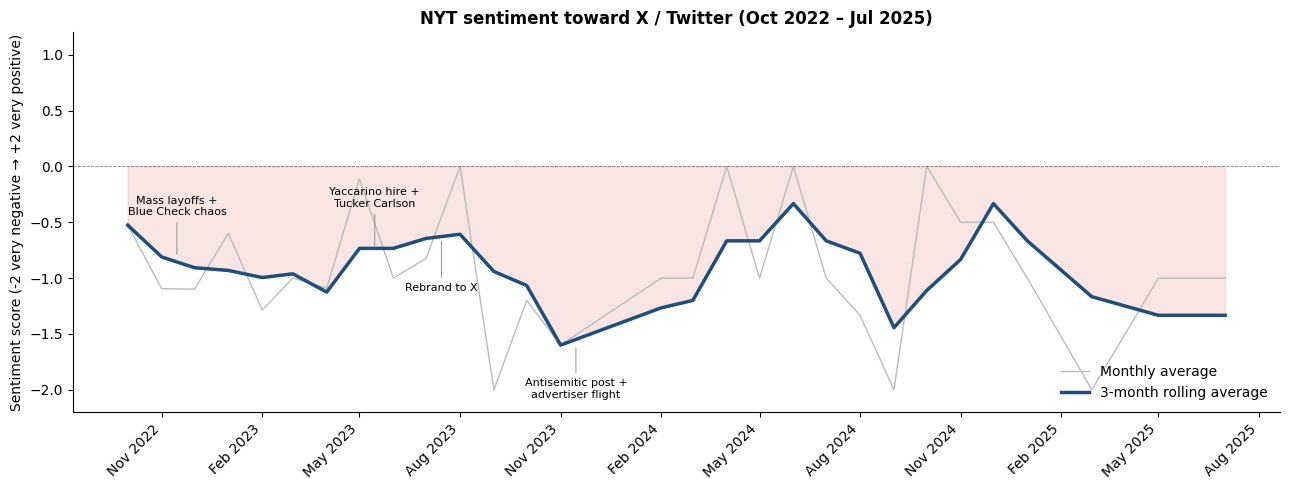

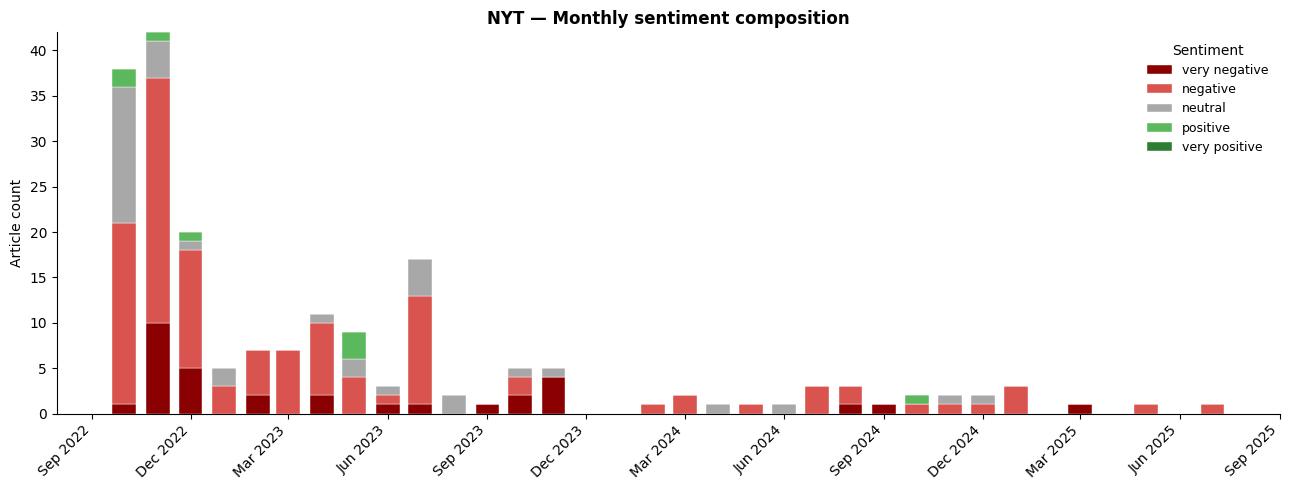

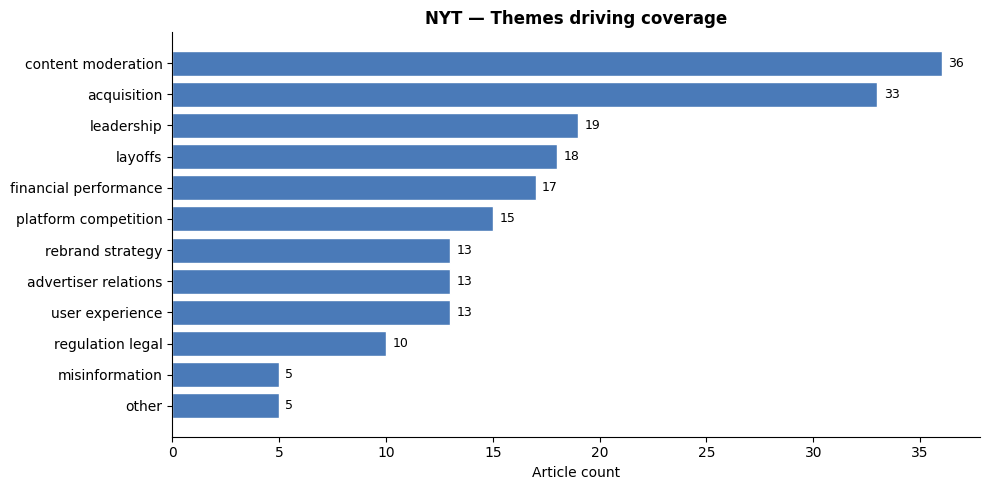

/tmp/ipykernel_1724/13578476.py:147: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  results["quarter"] = results["date"].dt.to_period("Q").astype(str)


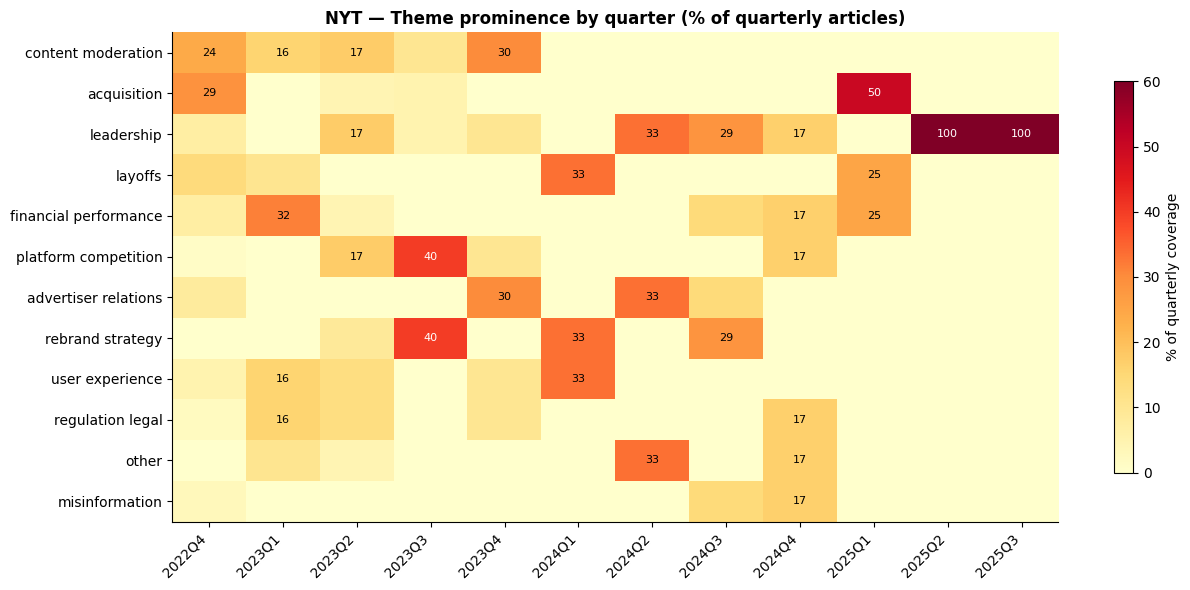

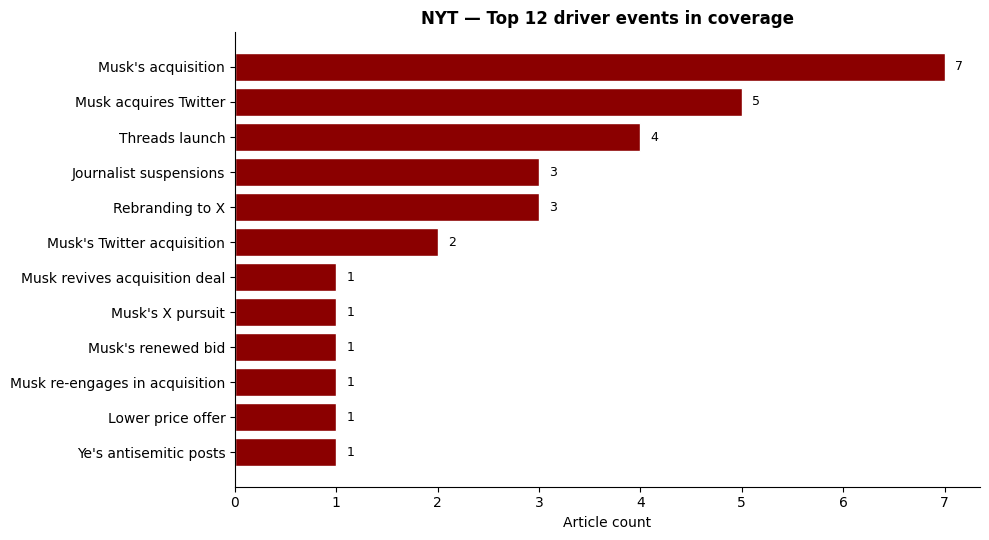


✓ All 5 NYT charts saved as PNGs (nyt_01_… through nyt_05_…)


In [29]:
# =============================================================
# NYT — VISUALISATIONS (5 charts)
# Mirrors Guardian chart suite for cross-source comparability.
# =============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# -----------------------
# Load and prep
# -----------------------
results = pd.read_csv("nyt_gemini_analysis.csv", parse_dates=["date"])
results = results.dropna(subset=["sentiment"]).copy()

sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}
results["sentiment_score"] = results["sentiment"].map(sentiment_score_map)
results["month"]    = results["date"].dt.to_period("M").astype(str)
results["month_dt"] = pd.to_datetime(results["month"])

COLOURS = {
    "very_negative": "#8B0000",
    "negative":      "#D9534F",
    "neutral":       "#A8A8A8",
    "positive":      "#5CB85C",
    "very_positive": "#2E7D32",
}
ORDER = ["very_negative", "negative", "neutral", "positive", "very_positive"]

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# =============================================================
# CHART 1 — Monthly average sentiment with rolling trend
# =============================================================
monthly_avg = (results.groupby("month_dt")["sentiment_score"]
                      .mean()
                      .reset_index()
                      .sort_values("month_dt"))
monthly_avg["rolling_3m"] = monthly_avg["sentiment_score"].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_avg["month_dt"], monthly_avg["sentiment_score"],
        color="#bbbbbb", linewidth=1, label="Monthly average")
ax.plot(monthly_avg["month_dt"], monthly_avg["rolling_3m"],
        color="#1f4e79", linewidth=2.5, label="3-month rolling average")

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
ax.fill_between(monthly_avg["month_dt"], monthly_avg["rolling_3m"], 0,
                where=(monthly_avg["rolling_3m"] < 0),
                color="#D9534F", alpha=0.15)

events = {
    "2022-11-15": ("Mass layoffs +\nBlue Check chaos", "top"),
    "2023-05-15": ("Yaccarino hire +\nTucker Carlson",  "top"),
    "2023-07-15": ("Rebrand to X",                       "bottom"),
    "2023-11-15": ("Antisemitic post +\nadvertiser flight", "bottom"),
}
for date_str, (label, pos) in events.items():
    d = pd.Timestamp(date_str)
    if d >= monthly_avg["month_dt"].min() and d <= monthly_avg["month_dt"].max():
        y = monthly_avg.loc[(monthly_avg["month_dt"] - d).abs().idxmin(), "rolling_3m"]
        offset = 30 if pos == "top" else -38
        ax.annotate(label, xy=(d, y), xytext=(0, offset),
                    textcoords="offset points", ha="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

ax.set_title("NYT sentiment toward X / Twitter (Oct 2022 – Jul 2025)")
ax.set_ylabel("Sentiment score (-2 very negative → +2 very positive)")
ax.set_xlabel("")
ax.set_ylim(-2.2, 1.2)
ax.legend(loc="lower right", frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("nyt_01_sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 2 — Stacked bar: sentiment composition by month
# =============================================================
sentiment_counts = (results.groupby(["month_dt", "sentiment"])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDER, fill_value=0)
                           .reset_index()
                           .sort_values("month_dt"))

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(sentiment_counts))
for s in ORDER:
    ax.bar(sentiment_counts["month_dt"], sentiment_counts[s],
           bottom=bottom, color=COLOURS[s],
           label=s.replace("_", " "), width=22, edgecolor="white", linewidth=0.3)
    bottom += sentiment_counts[s].values

ax.set_title("NYT — Monthly sentiment composition")
ax.set_ylabel("Article count")
ax.set_xlabel("")
ax.legend(title="Sentiment", loc="upper right", frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("nyt_02_sentiment_composition.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 3 — Theme frequency
# =============================================================
theme_counts = (results["primary_theme"]
                .value_counts()
                .reset_index())
theme_counts.columns = ["theme", "count"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(theme_counts["theme"].str.replace("_", " "),
               theme_counts["count"],
               color="#4a7ab8", edgecolor="white")
ax.invert_yaxis()
ax.set_title("NYT — Themes driving coverage")
ax.set_xlabel("Article count")
for bar, count in zip(bars, theme_counts["count"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("nyt_03_theme_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 4 — Theme heatmap by quarter
# =============================================================
results["quarter"] = results["date"].dt.to_period("Q").astype(str)

heatmap_data = (results.groupby(["quarter", "primary_theme"])
                       .size()
                       .unstack(fill_value=0))
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

theme_order = (heatmap_data.sum().sort_values(ascending=False).index.tolist())
heatmap_pct = heatmap_pct[theme_order]

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heatmap_pct.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=60)

ax.set_xticks(range(len(heatmap_pct.index)))
ax.set_xticklabels(heatmap_pct.index, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_pct.columns)))
ax.set_yticklabels([t.replace("_", " ") for t in heatmap_pct.columns])
ax.set_title("NYT — Theme prominence by quarter (% of quarterly articles)")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% of quarterly coverage")

for i in range(heatmap_pct.shape[0]):
    for j in range(heatmap_pct.shape[1]):
        v = heatmap_pct.iloc[i, j]
        if v >= 15:
            ax.text(i, j, f"{v:.0f}", ha="center", va="center",
                    color="white" if v > 35 else "black", fontsize=8)

plt.tight_layout()
plt.savefig("nyt_04_theme_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# =============================================================
# CHART 5 — Top driver events
# =============================================================
top_drivers = (results["driver_event"]
               .dropna()
               .value_counts()
               .head(12)
               .reset_index())
top_drivers.columns = ["driver", "count"]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(top_drivers["driver"], top_drivers["count"],
               color="#8B0000", edgecolor="white")
ax.invert_yaxis()
ax.set_title("NYT — Top 12 driver events in coverage")
ax.set_xlabel("Article count")
for bar, count in zip(bars, top_drivers["count"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(count), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("nyt_05_top_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✓ All 5 NYT charts saved as PNGs (nyt_01_… through nyt_05_…)")

/tmp/ipykernel_1724/3717616289.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_source["date"].dt.to_period("M").astype(str)
/tmp/ipykernel_1724/3717616289.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_source["date"].dt.to_period("M").astype(str)


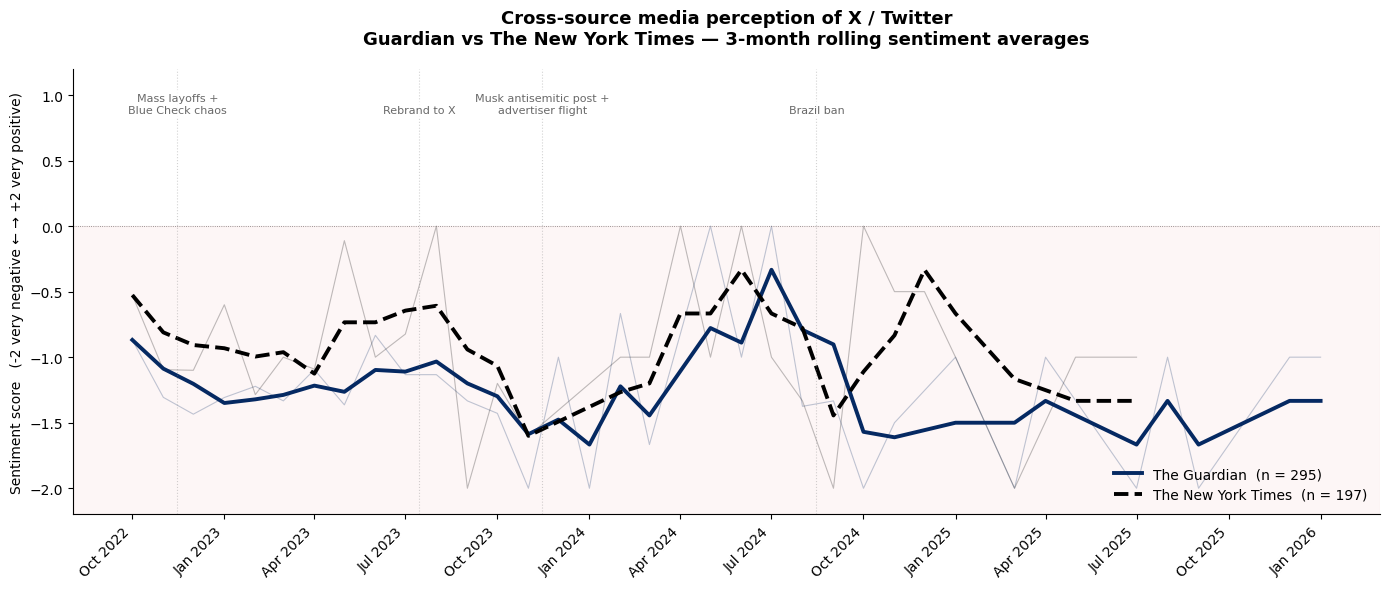

CROSS-SOURCE STATISTICS

Guardian:
  Articles: 295
  Mean sentiment score: -1.22
  % very_negative: 30.5%
  % negative or worse: 92.9%

NYT:
  Articles: 197
  Mean sentiment score: -0.89
  % very_negative: 16.2%
  % negative or worse: 76.6%

Correlation of monthly rolling averages: 0.53
(Months where both sources have data: 26)


In [31]:
# =============================================================
# CROSS-SOURCE COMPARISON: Guardian vs NYT
# Single most important chart of the assignment.
# =============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -----------------------
# Load both classified datasets
# -----------------------
guardian = pd.read_csv("gemini_analysis.csv", parse_dates=["date"])
guardian = guardian.dropna(subset=["sentiment"]).copy()
guardian["source"] = "The Guardian"

nyt = pd.read_csv("nyt_gemini_analysis.csv", parse_dates=["date"])
nyt = nyt.dropna(subset=["sentiment"]).copy()
nyt["source"] = "The New York Times"

# -----------------------
# Map sentiment to numeric and build monthly averages per source
# -----------------------
sentiment_score_map = {
    "very_negative": -2, "negative": -1, "neutral": 0,
    "positive": 1, "very_positive": 2,
}

def monthly_trajectory(df_source):
    df_source["sentiment_score"] = df_source["sentiment"].map(sentiment_score_map)
    df_source["month"] = pd.to_datetime(
        df_source["date"].dt.to_period("M").astype(str)
    )
    monthly = (df_source.groupby("month")
                        .agg(avg=("sentiment_score", "mean"),
                             n  =("sentiment_score", "size"))
                        .reset_index())
    monthly["rolling_3m"] = monthly["avg"].rolling(3, min_periods=1).mean()
    return monthly

g_monthly = monthly_trajectory(guardian)
n_monthly = monthly_trajectory(nyt)

# -----------------------
# Style
# -----------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GUARDIAN_COLOUR = "#052962"   # Guardian's actual brand blue
NYT_COLOUR      = "#000000"   # NYT's signature black
SHADE_NEG       = "#D9534F"

# -----------------------
# Chart
# -----------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Faint monthly lines (the noise — for transparency about the underlying volatility)
ax.plot(g_monthly["month"], g_monthly["avg"],
        color=GUARDIAN_COLOUR, linewidth=0.8, alpha=0.25)
ax.plot(n_monthly["month"], n_monthly["avg"],
        color=NYT_COLOUR, linewidth=0.8, alpha=0.25)

# Bold rolling lines (the actual signal)
ax.plot(g_monthly["month"], g_monthly["rolling_3m"],
        color=GUARDIAN_COLOUR, linewidth=2.8,
        label=f"The Guardian  (n = {len(guardian)})")
ax.plot(n_monthly["month"], n_monthly["rolling_3m"],
        color=NYT_COLOUR, linewidth=2.8, linestyle="--",
        label=f"The New York Times  (n = {len(nyt)})")

# Reference and shading
ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
ax.axhspan(0, -2.2, color=SHADE_NEG, alpha=0.05)

# Annotate the convergence story
events = {
    "2022-11-15": "Mass layoffs +\nBlue Check chaos",
    "2023-07-15": "Rebrand to X",
    "2023-11-15": "Musk antisemitic post +\nadvertiser flight",
    "2024-08-15": "Brazil ban",
}
combined_min = min(g_monthly["month"].min(), n_monthly["month"].min())
combined_max = max(g_monthly["month"].max(), n_monthly["month"].max())

for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    if combined_min <= d <= combined_max:
        ax.axvline(d, color="grey", linestyle=":", alpha=0.35, linewidth=0.8)
        ax.annotate(label, xy=(d, 0.85), ha="center", va="bottom",
                    fontsize=8, color="dimgrey",
                    bbox=dict(boxstyle="round,pad=0.3",
                              facecolor="white", edgecolor="none", alpha=0.85))

# Labels and chrome
ax.set_title(
    "Cross-source media perception of X / Twitter\n"
    "Guardian vs The New York Times — 3-month rolling sentiment averages",
    pad=18,
)
ax.set_ylabel("Sentiment score   (-2 very negative ← → +2 very positive)")
ax.set_xlabel("")
ax.set_ylim(-2.2, 1.2)
ax.legend(loc="lower right", frameon=False, fontsize=10)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("cross_source_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# -----------------------
# Summary statistics for the write-up
# -----------------------
print("=" * 60)
print("CROSS-SOURCE STATISTICS")
print("=" * 60)
print(f"\nGuardian:")
print(f"  Articles: {len(guardian)}")
print(f"  Mean sentiment score: {guardian['sentiment_score'].mean():.2f}")
print(f"  % very_negative: {(guardian['sentiment'] == 'very_negative').mean() * 100:.1f}%")
print(f"  % negative or worse: {guardian['sentiment'].isin(['negative','very_negative']).mean() * 100:.1f}%")

print(f"\nNYT:")
print(f"  Articles: {len(nyt)}")
print(f"  Mean sentiment score: {nyt['sentiment_score'].mean():.2f}")
print(f"  % very_negative: {(nyt['sentiment'] == 'very_negative').mean() * 100:.1f}%")
print(f"  % negative or worse: {nyt['sentiment'].isin(['negative','very_negative']).mean() * 100:.1f}%")

# Correlation between the two sources
merged = g_monthly.merge(n_monthly, on="month", suffixes=("_g", "_n"))
if len(merged) >= 5:
    correlation = merged["rolling_3m_g"].corr(merged["rolling_3m_n"])
    print(f"\nCorrelation of monthly rolling averages: {correlation:.2f}")
    print(f"(Months where both sources have data: {len(merged)})")